# Frequency-domain inspection

This notebook inspects the FFT of a sample recording and identifies its dominant spectral peaks. It is an exploratory diagnostic, not part of model training.

> Change the input filename when comparing a different excitation frequency. Shared spectral feature calculations are maintained in `src/machine_sentinel/features.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../../data/raw/120hz.csv')  # Change this file to inspect another recording

In [3]:
N = 200
FS = 200

window = df.iloc[200:400]

z_g = window['az'].to_numpy() / 4096.0
z_centered = z_g - np.mean(z_g)


In [4]:
fft_values = np.fft.rfft(z_centered)

frequencies = np.fft.rfftfreq(N, d=1/FS)

magnitudes = np.abs(fft_values)

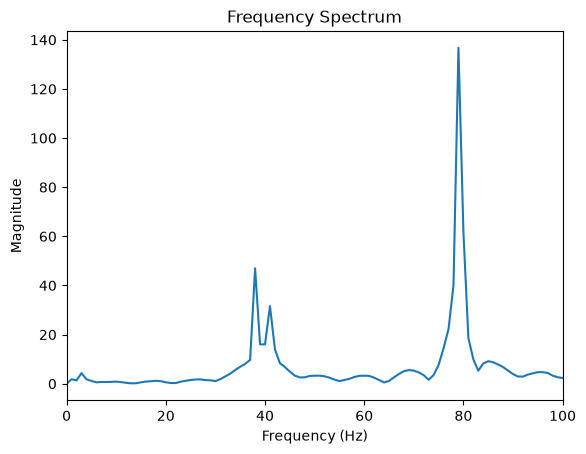

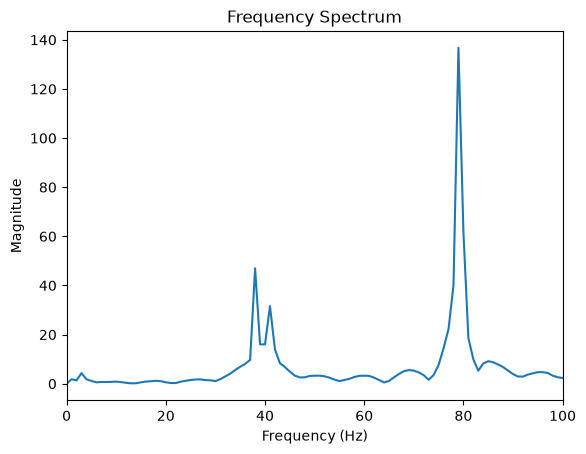

In [5]:
plt.figure()

plt.plot(frequencies, magnitudes)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")

plt.xlim(0, 100)

plt.show()
plt.figure()

plt.plot(frequencies, magnitudes)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")

plt.xlim(0, 100)

plt.show()

In [6]:
dominant_idx = np.argmax(magnitudes[1:]) + 1

dominant_frequency = frequencies[dominant_idx]

print("Dominant frequency:", dominant_frequency)

Dominant frequency: 79.0


In [7]:
indices = np.argsort(magnitudes[1:])[-5:] + 1

for idx in indices[::-1]:
    print(
        frequencies[idx],
        magnitudes[idx]
    )

79.0 136.79409397395227
80.0 61.785284200743654
38.0 46.98488630546177
78.0 40.09455493308119
41.0 31.595104603608984
